In [13]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 27.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
def route_cost(route, dist):
    return sum(dist[route[i], route[(i+1) % len(route)]] for i in range(len(route)))

def propose(route):
    r = route.copy()
    i, j = np.random.choice(len(r), 2, replace=False)
    r[i], r[j] = r[j], r[i]
    return r

def simulated_annealing(dist, n_iter=50000):
    route = np.random.permutation(len(dist))
    best, best_cost = route.copy(), route_cost(route, dist)
    cur_cost = best_cost

    for k in range(n_iter):
        T = 1 / np.sqrt(1 + k)          # cooling 
        proposal = propose(route)
        delta = route_cost(proposal, dist) - cur_cost
        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            route, cur_cost = proposal, cur_cost + delta
        if cur_cost < best_cost:
            best, best_cost = route.copy(), cur_cost

    return best, best_cost

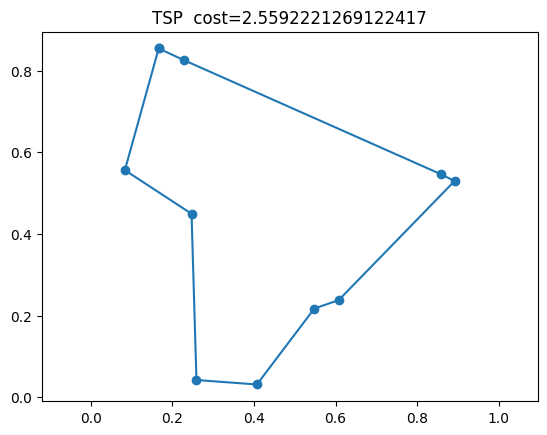

In [ ]:
#part 1
n = 10
cities = np.random.rand(n, 2)
dist = np.linalg.norm(cities[:,None] - cities[None,:], axis=-1)

route, cost = simulated_annealing(dist)
pts = cities[np.append(route, route[0])]
plt.plot(pts[:,0], pts[:,1], 'o-')
plt.title(f"cost={cost}"); plt.axis("equal"); plt.show()

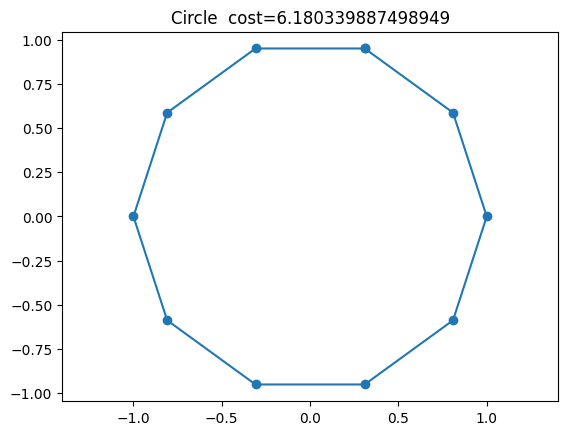

In [ ]:
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
cities = np.column_stack([np.cos(angles), np.sin(angles)])
dist = np.linalg.norm(cities[:,None] - cities[None,:], axis=-1)

route, cost = simulated_annealing(dist)
pts = cities[np.append(route, route[0])]
plt.plot(pts[:,0], pts[:,1], 'o-')
plt.title(f"cost={cost}"); plt.axis("equal"); plt.show()

In [ ]:
# part 2 

A = pd.read_csv('cost.csv', header=None).values.astype(float)
route, cost = simulated_annealing(A, n_iter=100000)
print("route found:", route + 1)
print("cost: ", round(cost, 1))

Best route found: [ 9 14 19 15 12  6  1 13  4  8  5 10 16 18  3 11 20  7 17  2]
Best cost:  1122.0
